In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split


In [2]:
titanic=sns.load_dataset("titanic")

In [3]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [12]:
features=["pclass","sex","fare","embarked","age"]
target=["survived"]

In [7]:
from sklearn.impute import SimpleImputer

imp_median=SimpleImputer(strategy="median")
titanic[["age"]]=imp_median.fit_transform(titanic[["age"]])

imp_freq=SimpleImputer(strategy="most_frequent")
titanic[["embarked"]]=imp_freq.fit_transform

In [8]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,<bound method TransformerMixin.fit_transform o...,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,<bound method TransformerMixin.fit_transform o...,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,<bound method TransformerMixin.fit_transform o...,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,<bound method TransformerMixin.fit_transform o...,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,<bound method TransformerMixin.fit_transform o...,Third,man,True,NaN,Southampton,no,True


In [9]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

titanic["sex"]=le.fit_transform(titanic["sex"])
titanic["embarked"]=le.fit_transform(titanic["embarked"])


In [14]:
X=titanic[features]
y=titanic[target]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [17]:
from sklearn.tree import DecisionTreeClassifier

model=DecisionTreeClassifier()
model.fit(X_train,y_train)



DecisionTreeClassifier()

In [18]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

y_pred=model.predict(X_test)
print("accuracy:",accuracy_score(y_test,y_pred))

accuracy: 0.7318435754189944


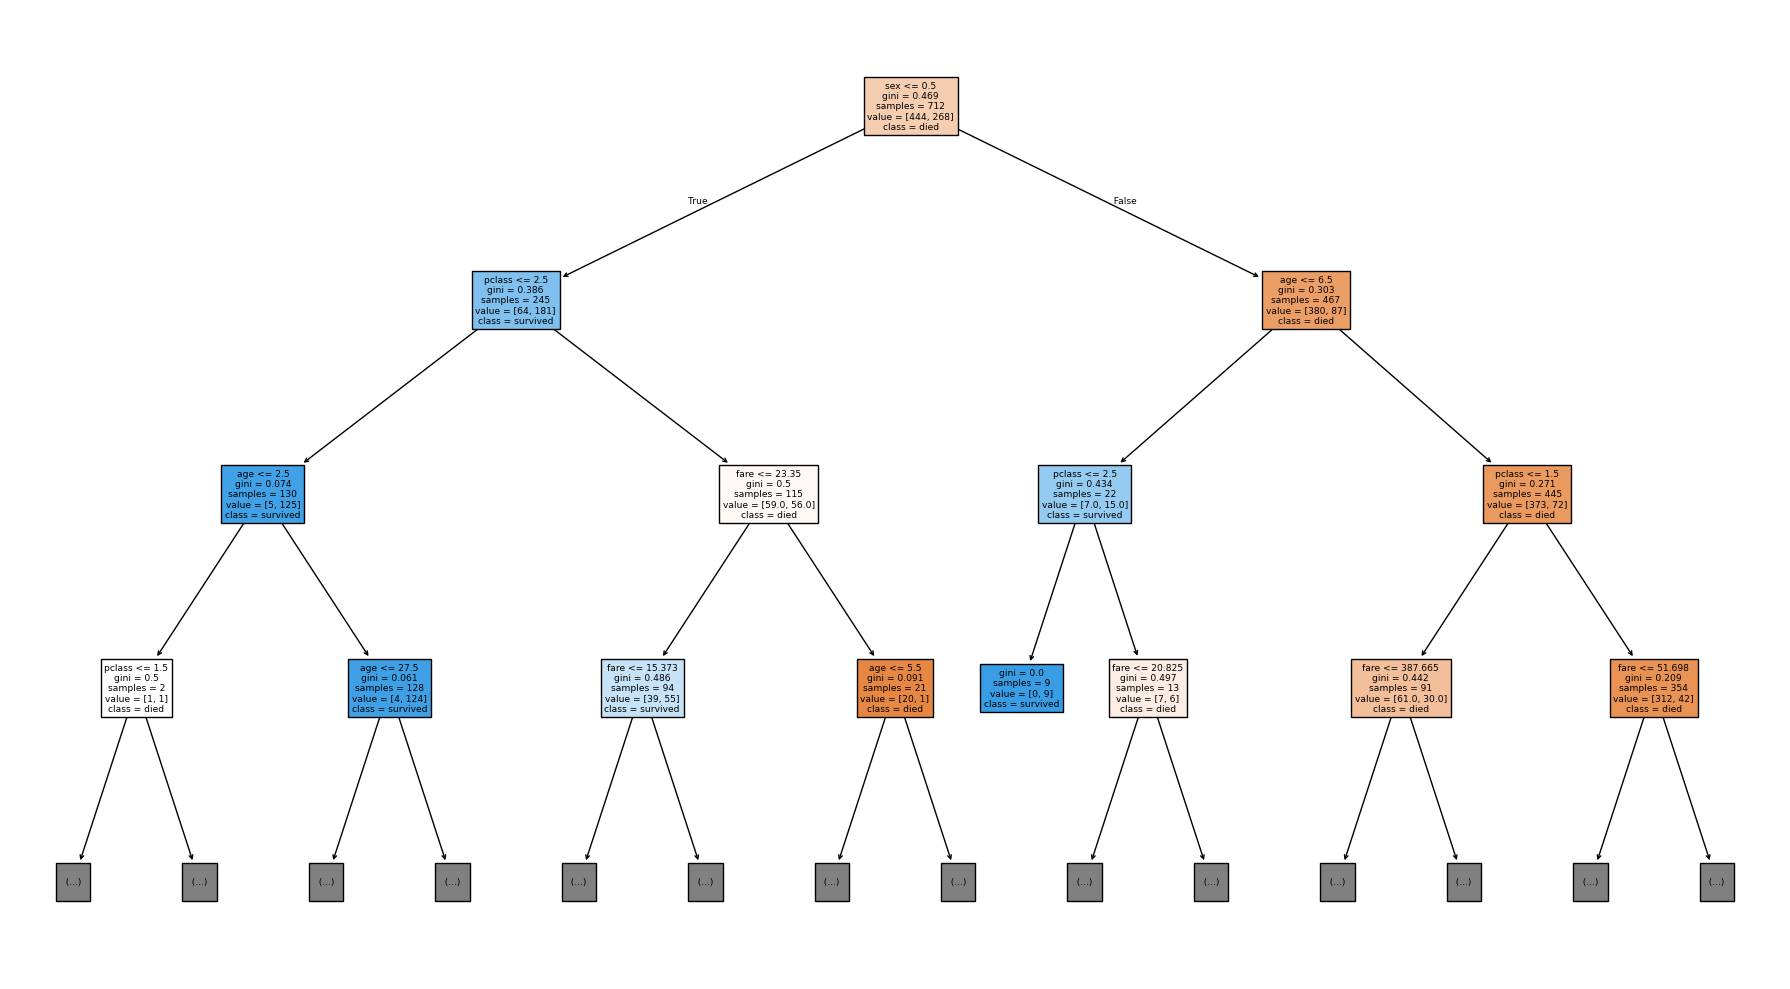

In [20]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["died","survived"],
    filled=True,
    max_depth=3
)

plt.tight_layout()

plt.show()

Decision Tree With Pre Pruning

In [21]:
max_depths=[2,3,4,5,6,7,8,9,10]

for depth in max_depths:
    model=DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)

    accuracy=model.score(X_test,y_test)
    print("max_depth:",depth,"accuracy:",accuracy)



max_depth: 2 accuracy: 0.7653631284916201
max_depth: 3 accuracy: 0.7988826815642458
max_depth: 4 accuracy: 0.7988826815642458
max_depth: 5 accuracy: 0.8044692737430168
max_depth: 6 accuracy: 0.7932960893854749
max_depth: 7 accuracy: 0.7653631284916201
max_depth: 8 accuracy: 0.7877094972067039
max_depth: 9 accuracy: 0.770949720670391
max_depth: 10 accuracy: 0.7821229050279329


In [24]:
min_splits=[5,10,15,20,25,30]

for split in min_splits:
    model=DecisionTreeClassifier(max_depth=5,min_samples_split=split)
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)

    accuracy=model.score(X_test,y_test)
    print("min_Split:",split,"accuracy:",accuracy)

min_Split: 5 accuracy: 0.8044692737430168
min_Split: 10 accuracy: 0.8044692737430168
min_Split: 15 accuracy: 0.7988826815642458
min_Split: 20 accuracy: 0.7988826815642458
min_Split: 25 accuracy: 0.7932960893854749
min_Split: 30 accuracy: 0.7932960893854749


Post Pruning

In [25]:
full_tree=DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [27]:
path=full_tree.cost_complexity_pruning_path(X_train,y_train)
ccp_alphas=path.ccp_alphas

print(ccp_alphas)

[0.00000000e+00 0.00000000e+00 6.68806849e-05 1.01334371e-04
 1.09441121e-04 2.34082397e-04 2.34082397e-04 3.56696986e-04
 4.18884289e-04 4.68164794e-04 5.61797753e-04 6.24219725e-04
 6.67991230e-04 7.02247191e-04 8.19288390e-04 8.42696629e-04
 8.71525724e-04 8.94231048e-04 9.24769963e-04 9.36329588e-04
 9.36329588e-04 9.36329588e-04 9.36329588e-04 9.63081862e-04
 9.88347898e-04 1.02010645e-03 1.05337079e-03 1.05637184e-03
 1.07400895e-03 1.11224953e-03 1.12359551e-03 1.12359551e-03
 1.12359551e-03 1.20385233e-03 1.21570845e-03 1.22893258e-03
 1.22893258e-03 1.22893258e-03 1.26404494e-03 1.27565833e-03
 1.28745318e-03 1.28745318e-03 1.30996111e-03 1.32395694e-03
 1.33761370e-03 1.47927070e-03 1.51142557e-03 1.54340042e-03
 1.81184917e-03 2.00538236e-03 2.02916600e-03 2.03651685e-03
 2.10674157e-03 2.10674157e-03 2.16292135e-03 2.24468299e-03
 2.64273538e-03 2.69412911e-03 4.11838599e-03 5.47433606e-03
 9.05540038e-03 1.39295081e-02 1.59241633e-02 3.86053527e-02
 1.37779976e-01]


In [29]:
tree=[]

for ccp_alpha in ccp_alphas:
    model=DecisionTreeClassifier(random_state=42,ccp_alpha=ccp_alpha)
    model.fit(X_train,y_train)

    tree.append((model,ccp_alpha))

In [30]:
best_acc=0
best_alpha=0

for model,alpha in tree:
  curr_acc=model.score(X_test,y_test)

  if curr_acc>best_acc:
    best_acc=curr_acc
    best_alpha=alpha

print("Best Accuracy:",best_acc)
print("Best Alpha:",best_alpha)

Best Accuracy: 0.8324022346368715
Best Alpha: 0.0020291660038851047


In [40]:
best_model=DecisionTreeClassifier(random_state=42,ccp_alpha=best_alpha,max_depth=5)

best_model.fit(X_train,y_train)

DecisionTreeClassifier(ccp_alpha=np.float64(0.0020291660038851047), max_depth=5,
                       random_state=42)

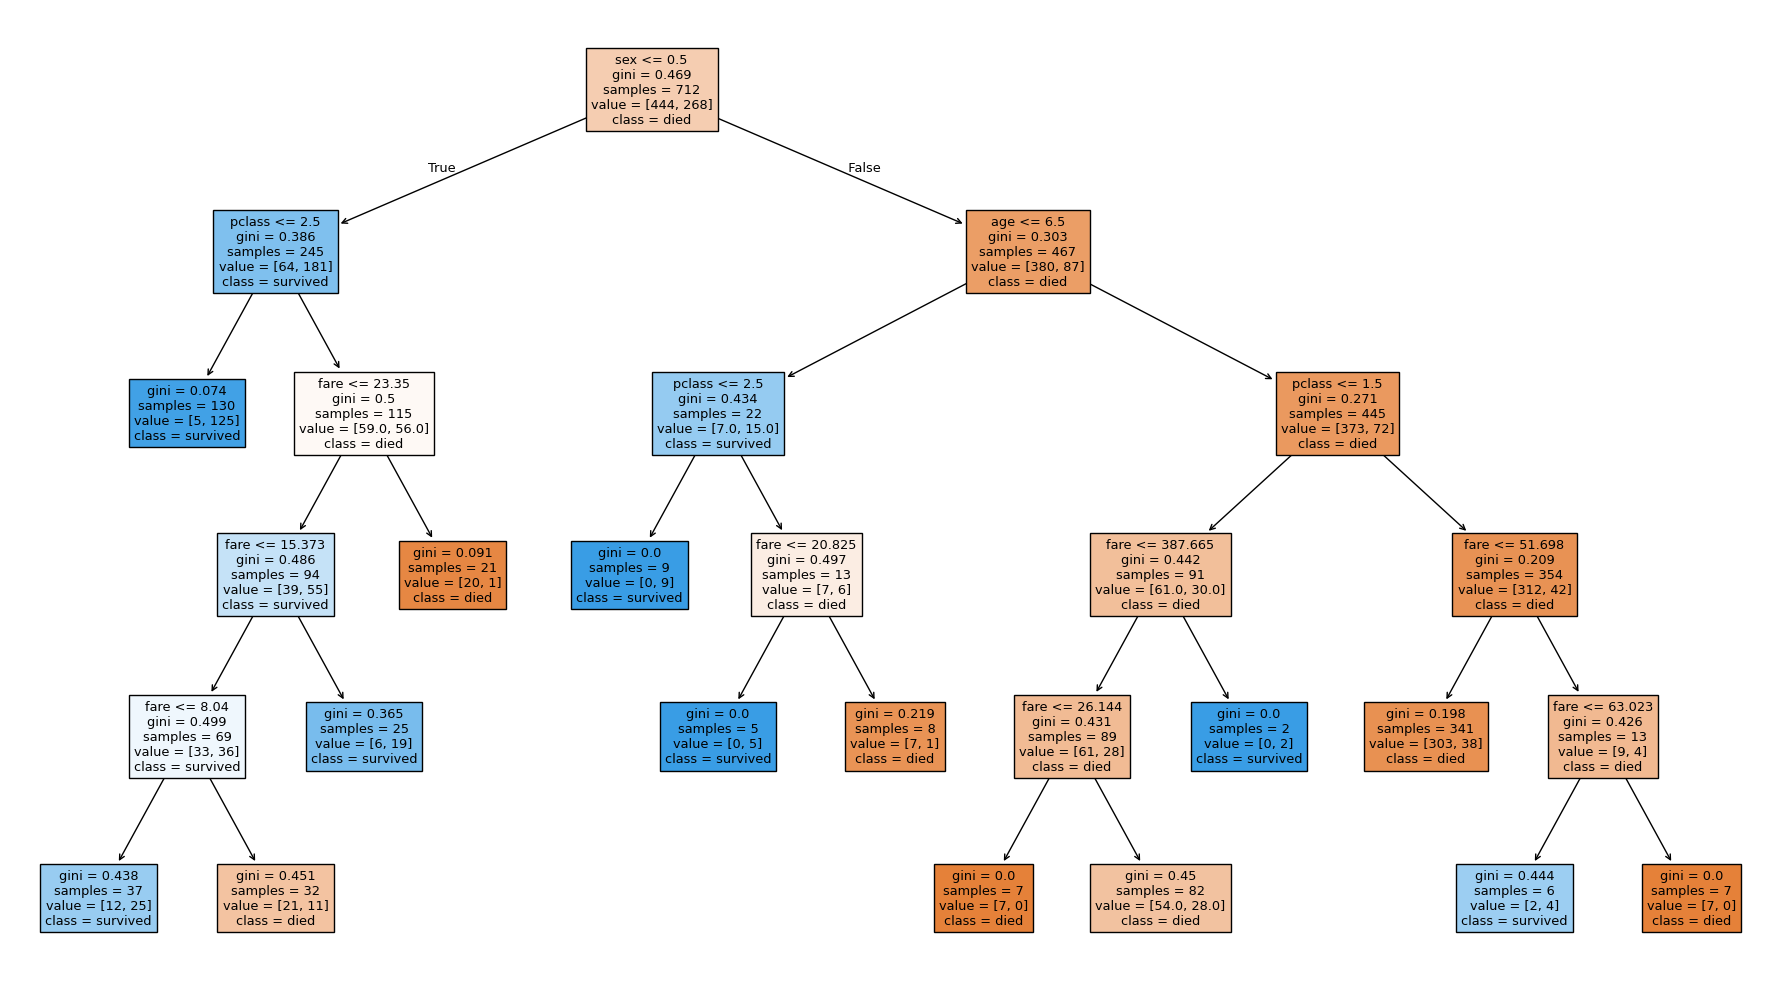

In [41]:
plt.figure(figsize=(18,10))

plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=["died","survived"],
    filled=True,

)

plt.tight_layout()

plt.show()

In [42]:
print("best model score:",best_model.score(X_test,y_test))

best model score: 0.8044692737430168
